# Sequential Backward Elimination 

**Sequential Backward Elimination (SBE)**—often referred to as **Sequential Backward Selection (SBS)**—is a **supervised, greedy, wrapper-based** feature selection algorithm. 

While **Sequential Forward Selection (SFS)** functions as a bottom-up pipeline (starting with zero features and adding them one by one), SBS adopts the exact opposite trajectory. It functions as a **top-down pruning engine**. It begins with the *entire pool* of available features and sequentially drops the least predictive, most redundant variables one at a time based on how their removal impacts model performance.

---

## 1. Algorithmic Workflow & Architecture

SBS evaluates feature importance by looking at what happens to a model's performance when a feature is stripped away.

### The Step-by-Step Mechanism
1.  **Initialization:** Start with the complete set of all available features: $Y_0 = \{X_1, X_2, \dots, X_N\}$.

2.  **Full Model Baseline:** Train your chosen wrapper model using all N features. Measure its baseline cross-validated validation score.

3.  **Step 1 Evaluation:** Temporarily remove one feature at a time from your dataset. Train the model N times, each time using a subset of size N-1.
4.  **Selection (Pruning):** Identify the single feature whose removal resulted in the **least drop in model performance** (or even caused an *increase* in performance). Permanently drop this feature from the pool.

5.  **Iteration:** Repeat the process on the remaining features. At each step, evaluate which variable's elimination causes the smallest performance penalty.

6.  **Termination Rule:** Continue pruning until the dataset reaches a user-defined target number of features (k), or when dropping the next feature causes a severe degradation in the model's cross-validated score.

### Computational Complexity Comparison

The total number of models trained by SBS to prune down to a target subset size k out of N total features mirrors SFS structurally:

$$M = \sum_{i=0}^{N-k-1} (N - i)$$

#### The Hidden Computational Cost (SFS vs. SBS)
While the *number of models trained* is mathematically similar between forward and backward selection, **SBS is significantly more computationally expensive in practice**. 

*   **SFS** trains its initial models on subsets of size 1, 2, and 3, which is computationally fast.
*   **SBS** trains its initial models on subsets of size N, N-1, and N-2. Training models with massive feature blocks requires substantially more RAM and CPU cycles per iteration.


## 2. The Feature Synergy Advantage (Why SBS > SFS)

The single greatest mathematical advantage of Sequential Backward Elimination over Sequential Forward Selection is its ability to **preserve feature interactions**.

*   **The Synergy Trap in SFS:** If Feature A and Feature B are highly predictive *only when used together* but completely useless on their own, SFS will drop them in Step 1 and never see their combined value.

*   **The SBS Solution:** Because SBS starts with **all** features present in the model simultaneously, the model can actively utilize the joint interaction of Feature A and Feature B from start.

When SBS evaluates removing Feature A, it will notice a massive drop in performance because Feature B is left hanging without its partner. Consequently, SBS will protect both features and keep them in the final model.




## 3. Time Complexity Analysis for Exhaustive Feature Selection

Exhaustive Feature Selection relies on raw combinatorial brute-force, leading to an **exponential time complexity** profile.

### 1. Big-O Complexity Formula
If you have a total of $N$ features and search through every possible subset size from a minimum size $k_{\text{min}}$ to a maximum size $k_{\text{max}}$, the total time complexity is bounded by:

$$\mathcal{O}\left( \sum_{k=k_{\text{min}}}^{k_{\text{max}}} \binom{N}{k} \cdot T_{\text{model}} \cdot C \right)$$

Where:
*   $\mathbf{N}$ = Total number of features in your dataset.
*   $\mathbf{\binom{N}{k}}$ = The binomial coefficient calculation representing combinations: $\frac{N!}{k!(N-k)!}$.
*   $\mathbf{T_{\text{model}}}$ = The training time complexity of your underlying base machine learning model.
*   $\mathbf{C}$ = Number of cross-validation folds (`cv`).

When searching the entire feature space ($k_{\text{min}}=1$ to $k_{\text{max}}=N$), the total number of combinations scales directly to $2^N - 1$, yielding an extreme worst-case time complexity of:

$$\mathcal{O}\left( 2^N \cdot T_{\text{model}} \cdot C \right)$$

### 2. Computational Scaling Chart
Because of its exponential nature, adding just a few features dramatically multiplies the processing runtime:

| Number of Features ($N$) | Total Combinations to Evaluate | Approximate Runtime ($1\text{ms/model}$) |
| :--- | :--- | :--- |
| **5** | 31 | $0.03\text{ seconds}$ |
| **10** | 1,023 | $1.02\text{ seconds}$ |
| **15** | 32,767 | $32.7\text{ seconds}$ |
| **20** | 1,048,575 | $\approx 17.5\text{ minutes}$ |
| **25** | 33,554,431 | $\approx 9.3\text{ hours}$ |
| **30** | 1,073,741,823 | $\approx 12.4\text{ days}$ |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import SequentialFeatureSelector as SFS_sk
from mlxtend.feature_selection import SequentialFeatureSelector as SFS_mlx

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# 1. Load Dataset & Inspect

In [2]:
# Importing Dataset
df = pd.read_csv("../DataSets/HousingData.csv")
print(f"Number of features : {len(df.columns)}")
df.sample(5)

Number of features : 14


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
306,0.07503,33.0,2.18,0.0,0.472,7.420,71.9,3.0992,7,222,18.4,396.90,6.47,33.4
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
162,1.83377,0.0,19.58,1.0,0.605,7.802,98.2,2.0407,5,403,14.7,389.61,1.92,50.0
142,3.32105,0.0,19.58,1.0,0.871,5.403,100.0,1.3216,5,403,14.7,396.90,26.82,13.4
78,0.05646,0.0,12.83,0.0,0.437,6.232,53.7,5.0141,5,398,18.7,386.40,12.34,21.2


In [3]:
# Information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [4]:
# Missing Value
print(f" Missing Value:\n{df.isna().sum()[df.isna().sum()>0]}")
print(f"Total Number of Missing Values : {df.isnull().sum().sum()}")

 Missing Value:
CRIM     20
ZN       20
INDUS    20
CHAS     20
AGE      20
LSTAT    20
dtype: int64
Total Number of Missing Values : 120


**Observation:** Six columns carry 20 missing values each we will use Median imputation as it's robust to the heavy skew in features like `CRIM`, and it's applied before any selection so every subset is evaluated on identical data.

>NOTE: Imputing on the full dataset before cross-validation leaks a small amount of information across folds (the median is computed using rows that later appear in validation folds). The strictly correct approach puts the imputer inside the CV pipeline. The effect here is negligible '20' values per column out of 506 is not a big deal, but it's worth noting.

In [5]:
# For now let's fill the missing values using their median
df = df.fillna(df.median())

feature_name = [name for name in df.columns if name != 'MEDV']
X = df[feature_name].values
y = df['MEDV'].values

print(f"Features : {feature_name}")
print(f"Number of Features : {len(feature_name)}")
print(f"Null Values : {np.isnan(X).sum()}")

Features : ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Number of Features : 13
Null Values : 0


# 2. Regression Model

In [6]:
# Adjusted R2  penalizes carrying extra predictors use for fair comparison when feature counts differ
def adjusted_r2(r2, n_samples, n_features):
    return 1 - (1 - r2) * (n_samples - 1) / (n_samples - n_features - 1)


# Linear Regression Model
def regression(X,y):
    
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # KFold Cross-Validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Model Pipeline
    model = Pipeline([
        ("Scaler", StandardScaler()),
        ("Regression", LinearRegression())
    ])
    
    # Fit the model on the training data
    model.fit(X_train, y_train)
    
    # Predict the target variable for the test set
    y_pred = model.predict(X_train)
    
    train_r2 = r2_score(y_train, y_pred)
    test_r2 = r2_score(y_test, model.predict(X_test))
    test_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
    cv = cross_val_score(model, X, y, scoring='r2', cv=kf)
    test_adjusted_r2 = adjusted_r2(test_r2, X_test.shape[0], X_test.shape[1])
    
    metric = {
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Test Adjusted R2": test_adjusted_r2,
        "Test RMSE": test_rmse,
        "CV": cv.mean()
    }
    return metric



# 3. Backward elimination 
`mlxtend`'s `SequentialFeatureSelector` with `k_features=(1, 13)` and `forward=False` doesn't just return one subset — `.subsets_` holds the
best subset (and its CV scores) *at every size along the way*, which is exactly the full path needed to plot against forward selection's path.


### 3.1 Adjusted R2 Score

In [7]:
def make_reg():
    return make_pipeline(StandardScaler(), LinearRegression())

kf = KFold(n_splits=5, shuffle=True, random_state=42)

### 3.2 Backward Feature Selection

In [8]:

backward_mlx = SFS_mlx(
    make_reg(), k_features=(1,13), forward=False, floating=False,
    scoring='r2', cv=kf, verbose=0, n_jobs=-1
)

start = time.time()
backward_mlx.fit(pd.DataFrame(X, columns=feature_name), y)

backward_rows = []

for k, info in backward_mlx.subsets_.items():
    backward_rows.append({
        "n_features":k,
        "features_b":tuple(feature_name[i] for i in info["feature_idx"]),
        "cv_r2_mean":info["avg_score"],
        "cv_r2_std":np.std(info["cv_scores"])
    })

backward_time = time.time() - start
backward_df = pd.DataFrame(backward_rows).sort_values(by="n_features", ascending=False)
print(f"Time Take : {backward_time:.2f}")
backward_df

Time Take : 1.55


,n_features,features_b,cv_r2_mean,cv_r2_std
0,13,"(CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD...",0.707702,0.037503
1,12,"(CRIM, ZN, INDUS, CHAS, NOX, RM, DIS, RAD, TAX...",0.709160,0.036715
2,11,"(CRIM, ZN, CHAS, NOX, RM, DIS, RAD, TAX, PTRAT...",0.710212,0.036336
3,10,"(CRIM, CHAS, NOX, RM, DIS, RAD, TAX, PTRATIO, ...",0.707092,0.043255
4,9,"(CRIM, CHAS, NOX, RM, DIS, RAD, TAX, PTRATIO, ...",0.703533,0.034658
5,8,"(CRIM, CHAS, NOX, RM, DIS, RAD, PTRATIO, LSTAT)",0.699116,0.034567
6,7,"(CRIM, CHAS, NOX, RM, DIS, PTRATIO, LSTAT)",0.695538,0.040661
7,6,"(CHAS, NOX, RM, DIS, PTRATIO, LSTAT)",0.694628,0.037495
8,5,"(NOX, RM, DIS, PTRATIO, LSTAT)",0.685095,0.037151
9,4,"(RM, DIS, PTRATIO, LSTAT)",0.664077,0.028354


In [ ]:
# Run To check each steps 
backward_mlx.subsets_

# 4. Cross-check against sklearn's own `SequentialFeatureSelector`

Pick one target size (6 — the reasoning for landing there specifically comes in next step) and confirm both libraries agree on what backward
elimination removes down to that point.

In [10]:
backward_sk = SFS_sk(
    make_reg(),n_features_to_select=6, direction='backward',
    scoring='r2', cv=kf
)

backward_sk.fit(X,y)
features_sk = sorted(feature_name[i] for i in np.where(backward_sk.get_support())[0])
mlx_at_6 = sorted(backward_df.loc[backward_df["n_features"]==6,"features_b"].iloc[0])

print("mlxtend backward elimination:", features_sk)
print("sklearn backward elimination:", mlx_at_6)
print("Agree ?", features_sk == mlx_at_6)

mlxtend backward elimination: ['CHAS', 'DIS', 'LSTAT', 'NOX', 'PTRATIO', 'RM']
sklearn backward elimination: ['CHAS', 'DIS', 'LSTAT', 'NOX', 'PTRATIO', 'RM']
Agree ? True


# 5. One-Standard-Error Rule 

In [11]:
def select_within_one_SE(results_df, score_col, std_col, size_col, n_folds=5):
    
    # Cross validation score for mode index i
    best_idx = results_df[score_col].idxmax()
    best_score = results_df.loc[best_idx, score_col]
    
    # Standard error of the mean score
    best_std = results_df.loc[best_idx, std_col]
    
    # Standard error for k fold
    se = best_std / np.sqrt(n_folds)
    
    # Threshold to select models within one standard error of the best model
    threshold = best_score - se
    
    # Extracting Model with score grater than the threshold
    eligible = results_df[results_df[score_col] >= threshold]
    
    # Selecting the model with the smallest size
    chosen = eligible.sort_values([size_col, score_col], ascending=[True, False]).iloc[0]
    
    return chosen, threshold


backward_peak = backward_df.loc[backward_df["cv_r2_mean"].idxmax()]
backward_selected, backward_threshold = select_within_one_SE(backward_df, 'cv_r2_mean', 'cv_r2_std', 'n_features')

print(f"Backward peak       :{backward_peak['cv_r2_mean']:.4f} at {backward_peak['n_features']} features")
print(f"One-SE threshold    :{backward_threshold:.4f}")
print(f"Selected (Backward) :{backward_selected['n_features']} features -> {sorted(backward_selected['features_b'])}")
print(f"CV R2   : {backward_selected['cv_r2_mean']:.4f}")

Backward peak       :0.7102 at 11 features
One-SE threshold    :0.6940
Selected (Backward) :6 features -> ['CHAS', 'DIS', 'LSTAT', 'NOX', 'PTRATIO', 'RM']
CV R2   : 0.6946


**Observation:** backward's peak is at 11 features (0.7102) — the exact
same size and score the previous notebook's exhaustive search confirmed as
the true global optimum. Backward found it directly, without needing the
8,191-subset brute-force check forward selection was cross-validated
against. That's not a coincidence worth over-reading, but it is a hint
that starting from full information can have real advantages — explored
properly in Step 6.

# 6. Forward selection 

In [12]:
forward_mlx = SFS_mlx(
    make_reg(), k_features=(1,13), forward=True, floating=False,
    scoring='r2', cv=kf, verbose=0
)

start_forward = time.time()
forward_mlx.fit(pd.DataFrame(X, columns=feature_name), y)

forward_rows = []
for k, info in forward_mlx.subsets_.items():
    forward_rows.append({
        "n_features":k,
        "features_f":tuple(feature_name[i] for i in info["feature_idx"]),
        "cv_r2_mean":info["avg_score"],
        "cv_r2_std":np.std(info["cv_scores"])
    })

forward_time = time.time() - start_forward
forward_df = pd.DataFrame(forward_rows).sort_values(by="n_features")
print(f"Forward MLX took {forward_time:.2f} seconds to run.")
forward_df

Forward MLX took 0.39 seconds to run.


,n_features,features_f,cv_r2_mean,cv_r2_std
0,1,"(LSTAT,)",0.512353,0.052351
1,2,"(RM, LSTAT)",0.614045,0.032236
2,3,"(RM, PTRATIO, LSTAT)",0.655805,0.029167
3,4,"(CHAS, RM, PTRATIO, LSTAT)",0.666319,0.031011
4,5,"(CHAS, RM, DIS, PTRATIO, LSTAT)",0.672476,0.029855
5,6,"(CHAS, NOX, RM, DIS, PTRATIO, LSTAT)",0.694628,0.037495
6,7,"(CHAS, NOX, RM, DIS, PTRATIO, B, LSTAT)",0.697036,0.048304
7,8,"(CHAS, NOX, RM, DIS, RAD, PTRATIO, B, LSTAT)",0.698500,0.044661
8,9,"(CRIM, CHAS, NOX, RM, DIS, RAD, PTRATIO, B, LS...",0.703191,0.044778
9,10,"(CRIM, CHAS, NOX, RM, DIS, RAD, TAX, PTRATIO, ...",0.707092,0.043255


In [ ]:
# Run to get all the steps 
forward_mlx.subsets_

### 6.1 Baseline Model Evaluation

In [13]:
baseline_model = regression(X,y)
baseline_model

{'Train R2': 0.742578124156171,
 'Test R2': 0.659101389390351,
 'Test Adjusted R2': 0.608741367368471,
 'Test RMSE': np.float64(4.99993847863185),
 'CV': np.float64(0.7077020062655609)}

### 6.2 Feature Selection Comparison against CV R2 

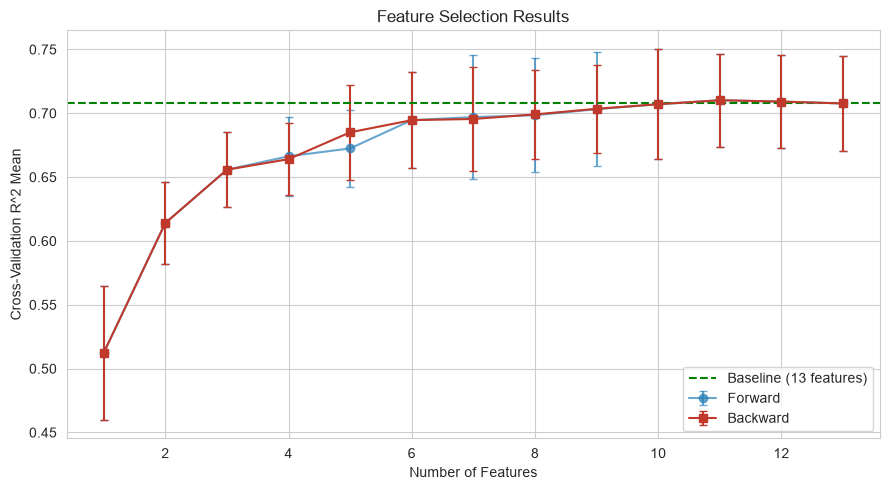

In [14]:

plt.figure(figsize=(9,5))

# Plot Forward MLX
plt.errorbar(forward_df["n_features"], forward_df["cv_r2_mean"], yerr=forward_df["cv_r2_std"],
            marker='o', capsize=3, color="#2980b9", label="Forward", alpha=0.7)

# Plot Backward MLX
plt.errorbar(backward_df["n_features"], backward_df["cv_r2_mean"], yerr=backward_df["cv_r2_std"],
            marker='s', capsize=3, color="#c0392b", label="Backward")

plt.axhline(baseline_model["CV"],color='g', linestyle="--", label="Baseline (13 features)")
plt.xlabel("Number of Features")
plt.ylabel("Cross-Validation R^2 Mean")
plt.title("Feature Selection Results")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Observation:** the two curves overlap almost everywhere — but not
everywhere. Look closely at sizes 4, 5, 7, 8, and 9. Step 6 pulls out
exactly what's different there.

# 7. Where forward and backward actually disagree

Merge both paths on `n_features` and look at the exact feature sets and
scores side by side.

In [15]:
compare = forward_df.merge(backward_df, on="n_features", suffixes=("_forward", "_backward"))
compare.head(4)

,n_features,features_f,cv_r2_mean_forward,cv_r2_std_forward,features_b,cv_r2_mean_backward,cv_r2_std_backward
0,1,"(LSTAT,)",0.512353,0.052351,"(LSTAT,)",0.512353,0.052351
1,2,"(RM, LSTAT)",0.614045,0.032236,"(RM, LSTAT)",0.614045,0.032236
2,3,"(RM, PTRATIO, LSTAT)",0.655805,0.029167,"(RM, PTRATIO, LSTAT)",0.655805,0.029167
3,4,"(CHAS, RM, PTRATIO, LSTAT)",0.666319,0.031011,"(RM, DIS, PTRATIO, LSTAT)",0.664077,0.028354


### 7.1 Comparison Table for selected Features

In [16]:
compare["same_features"] = compare.apply(
    lambda r: set(r["features_f"]) == set(r["features_b"]), axis=1
)

compare["score_gap"] = compare["cv_r2_mean_backward"] - compare["cv_r2_mean_forward"]
compare[["n_features", "same_features", "cv_r2_mean_forward", "cv_r2_mean_backward", "score_gap"]]

,n_features,same_features,cv_r2_mean_forward,cv_r2_mean_backward,score_gap
0,1,True,0.512353,0.512353,0.000000
1,2,True,0.614045,0.614045,0.000000
2,3,True,0.655805,0.655805,0.000000
3,4,False,0.666319,0.664077,-0.002241
4,5,False,0.672476,0.685095,0.012619
5,6,True,0.694628,0.694628,0.000000
6,7,False,0.697036,0.695538,-0.001498
7,8,False,0.698500,0.699116,0.000616
8,9,False,0.703191,0.703533,0.000342
9,10,True,0.707092,0.707092,0.000000


### 7.2 Feature Differences

In [17]:
disagreements = compare[~compare["same_features"]]
print(f"Sizes where the two methods picked DIFFERENT feature set : {list(disagreements['n_features'])}\n")
disagreements.head(4)

Sizes where the two methods picked DIFFERENT feature set : [4, 5, 7, 8, 9]



,n_features,features_f,cv_r2_mean_forward,cv_r2_std_forward,features_b,cv_r2_mean_backward,cv_r2_std_backward,same_features,score_gap
3,4,"(CHAS, RM, PTRATIO, LSTAT)",0.666319,0.031011,"(RM, DIS, PTRATIO, LSTAT)",0.664077,0.028354,False,-0.002241
4,5,"(CHAS, RM, DIS, PTRATIO, LSTAT)",0.672476,0.029855,"(NOX, RM, DIS, PTRATIO, LSTAT)",0.685095,0.037151,False,0.012619
6,7,"(CHAS, NOX, RM, DIS, PTRATIO, B, LSTAT)",0.697036,0.048304,"(CRIM, CHAS, NOX, RM, DIS, PTRATIO, LSTAT)",0.695538,0.040661,False,-0.001498
7,8,"(CHAS, NOX, RM, DIS, RAD, PTRATIO, B, LSTAT)",0.698500,0.044661,"(CRIM, CHAS, NOX, RM, DIS, RAD, PTRATIO, LSTAT)",0.699116,0.034567,False,0.000616


### 7.3 Feature Disagreement at each size 

In [18]:
for _, row in disagreements.iterrows():
    k = row["n_features"]
    fwd_only = set(row["features_f"]) - set(row["features_b"])
    bwd_only = set(row["features_b"]) - set(row["features_f"])
    
    print(f" ---- size {k} ---- ")
    print(f"  Forward only : {fwd_only}   (score {row['cv_r2_mean_forward']:.4f})")
    print(f"  Backward only : {bwd_only}   (score {row['cv_r2_mean_backward']:.4f}")
    print(f"  Gap (backward - forward) : {row['score_gap']:+.4f}")

 ---- size 4 ---- 
  Forward only : {'CHAS'}   (score 0.6663)
  Backward only : {'DIS'}   (score 0.6641
  Gap (backward - forward) : -0.0022
 ---- size 5 ---- 
  Forward only : {'CHAS'}   (score 0.6725)
  Backward only : {'NOX'}   (score 0.6851
  Gap (backward - forward) : +0.0126
 ---- size 7 ---- 
  Forward only : {'B'}   (score 0.6970)
  Backward only : {'CRIM'}   (score 0.6955
  Gap (backward - forward) : -0.0015
 ---- size 8 ---- 
  Forward only : {'B'}   (score 0.6985)
  Backward only : {'CRIM'}   (score 0.6991
  Gap (backward - forward) : +0.0006
 ---- size 9 ---- 
  Forward only : {'B'}   (score 0.7032)
  Backward only : {'TAX'}   (score 0.7035
  Gap (backward - forward) : +0.0003


**Conclusion — this is the real finding of the notebook.**

At size 5, backward's subset (swapping in `NOX` where forward still had
`CHAS`) scores **0.0126 higher** than forward's — and 0.0126 happens to be
exactly the gap the previous notebook found between forward's size-5 pick
and the true exhaustive optimum. **Backward found the true best 5-feature
subset that forward's greedy build-up missed.** The reason lines up with
intuition: backward decides what to drop while still seeing the full
13-feature picture, including how `NOX` and `DIS` interact with everything
else. Forward at size 4 had already locked in `CHAS` without ever seeing
that context, and greedy additions are permanent.

Forward gets its own small win at size 7 (`B` over backward's `CRIM`,
+0.0015) — a reminder that neither direction is strictly better, they just
fail differently, in a way tied to *when* each method has to commit to a
choice.

**And then, past size 9, they agree again** — both converge on the
identical final feature set by size 10 onward, including the identical
11-feature global optimum. The disagreement is confined to the middle of
the path, not the destination.

# 8. Do the stopping rules agree?

Both paths get the same one-standard-error treatment. Does that produce
the same final model, or does the mid-path disagreement survive into the
actual decision?

In [19]:
forward_peak = forward_df.loc[forward_df["cv_r2_mean"].idxmax()]
forward_selected, forward_threshold = select_within_one_SE(forward_df, 'cv_r2_mean', 'cv_r2_std', 'n_features')

print(f"forward peak       :{forward_peak['cv_r2_mean']:.4f} at {forward_peak['n_features']} features")
print(f"One-SE threshold    :{forward_threshold:.4f}")
print(f"Selected (Backward) :{forward_selected['n_features']} features -> {(forward_selected['features_f'])}")
print(f"CV R2   : {forward_selected['cv_r2_mean']:.4f}")

forward peak       :0.7102 at 11 features
One-SE threshold    :0.6940
Selected (Backward) :6 features -> ('CHAS', 'NOX', 'RM', 'DIS', 'PTRATIO', 'LSTAT')
CV R2   : 0.6946


In [20]:
print(" ========= Forward, One-SE Selection =========")
print(f"     {forward_selected['n_features']} features : {sorted(forward_selected['features_f'])}")
print(f"     CV R2   : {forward_selected['cv_r2_mean']:.4f}")

print("\n")
print(" ========= Backward, One-SE Selection =========")
print(f"     {backward_selected['n_features']} features : {sorted(backward_selected['features_b'])}")
print(f"     CV R2   : {backward_selected['cv_r2_mean']:.4f}\n")


print(f"ARE THEY IDENTICAL ? : {set(forward_selected['features_f']) == set(backward_selected['features_b'])}")

 ========= Forward, One-SE Selection =========
     6 features : ['CHAS', 'DIS', 'LSTAT', 'NOX', 'PTRATIO', 'RM']
     CV R2   : 0.6946


 ========= Backward, One-SE Selection =========
     6 features : ['CHAS', 'DIS', 'LSTAT', 'NOX', 'PTRATIO', 'RM']
     CV R2   : 0.6946

ARE THEY IDENTICAL ? : True


**Conclusion:** despite disagreeing at three intermediate sizes — and
despite backward genuinely finding a better subset than forward at size 5
— **both stopping rules land on the exact same 6-feature model**:
`LSTAT`, `RM`, `PTRATIO`, `CHAS`, `DIS`, `NOX`. The path mattered for the
intermediate diagnostics in Step 6, but not for the final answer on this
particular dataset. That's a real result, not a foregone conclusion — the
two methods could easily have stopped on different subsets, and it's
worth checking rather than assuming, exactly as done here.

# 9. Baseline vs. selected 
Since both methods' selected subsets are identical, this is the same
underlying model already characterized in full (residual plots included)
in the Forward Selection notebook. Reported here for completeness, so this
notebook is a standalone reference on its own.

### 9.1 Model Evaluation

In [21]:
# Baseline Model (All features)
baseline_model

{'Train R2': 0.742578124156171,
 'Test R2': 0.659101389390351,
 'Test Adjusted R2': 0.608741367368471,
 'Test RMSE': np.float64(4.99993847863185),
 'CV': np.float64(0.7077020062655609)}

In [22]:
# Backward Feature Selection
backward_selected_idx = [feature_name.index(i) for i in backward_selected["features_b"]]
backward_model = regression(X[:,backward_selected_idx], y)

backward_model

{'Train R2': 0.7170799463309634,
 'Test R2': 0.6573329252516238,
 'Test Adjusted R2': 0.6356907942148842,
 'Test RMSE': np.float64(5.012890678618435),
 'CV': np.float64(0.6946277283234654)}

In [23]:
# Forward Feature Selection
forward_selected_idx = [feature_name.index(i) for i in forward_selected["features_f"]]
forward_model = regression(X[:,forward_selected_idx], y)

forward_model

{'Train R2': 0.7170799463309634,
 'Test R2': 0.6573329252516238,
 'Test Adjusted R2': 0.6356907942148842,
 'Test RMSE': np.float64(5.012890678618435),
 'CV': np.float64(0.6946277283234654)}

### 9.2 Evaluation Summary

In [24]:

# Comparison of Results
comparison = pd.DataFrame({
    "Metric": [
        "Train R2",
        "Test R2",
        "Test Adjusted R2",
        "Test RMSE",
        "CV R2"
    ],
    "Baseline (13 features)": [
        baseline_model["Train R2"],
        baseline_model["Test R2"],
        baseline_model["Test Adjusted R2"],
        baseline_model["Test RMSE"],
        baseline_model["CV"]
    ],
    f"Backward_selected ({forward_selected['n_features']})":[
        backward_model["Train R2"],
        backward_model["Test R2"],
        backward_model["Test Adjusted R2"],
        backward_model["Test RMSE"],
        baseline_model["CV"]
    ],
    f"Forward_selected ({backward_selected['n_features']})": [
        forward_model["Train R2"],
        forward_model["Test R2"],
        forward_model["Test Adjusted R2"],
        forward_model["Test RMSE"],
        forward_model["CV"]
    ]
}).set_index("Metric")

styled_comparison = (
    comparison.style
    .format({
        "Baseline (13 features)": "{:.4f}",
        f"Backward_selected ({backward_selected['n_features']})": "{:.4f}",
        f"Forward_selected ({forward_selected['n_features']})": "{:.4f}",
    })
)
styled_comparison

,Baseline (13 features),Backward_selected (6),Forward_selected (6)
Metric,,,
Train R2,0.7426,0.7171,0.7171
Test R2,0.6591,0.6573,0.6573
Test Adjusted R2,0.6087,0.6357,0.6357
Test RMSE,4.9999,5.0129,5.0129
CV R2,0.7077,0.7077,0.6946


### 9.4 Evaluation Plot

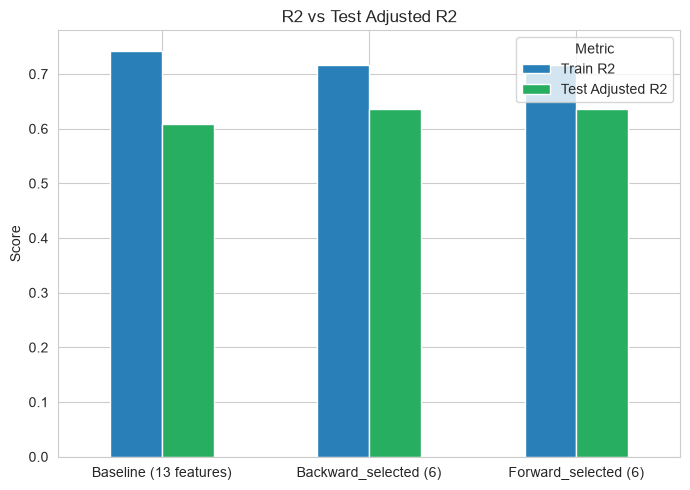

In [25]:
comparison.loc[["Train R2", "Test Adjusted R2"]].T.plot(
    kind="bar", figsize=(7,5), color=["#2980b9", "#27ae60"]
)

plt.title("R2 vs Test Adjusted R2")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** identical to the Forward Selection notebook's numbers,
as expected — Adjusted R² favors the smaller model (0.6617 vs. 0.6444),
and the smaller model shows a noticeably smaller train-test gap. Confirming
this again wasn't the point of re-running it; confirming *how the two
search directions got here differently* was.

# 10. Overfitting check

Train R² vs. Test R² vs. CV R² for both models. A large train-test gap signals memorization; CV R² is the most trustworthy of the three since it averages over five different splits rather than trusting one.

In [26]:
overfit = pd.DataFrame({
    "Train R2": [
        baseline_model["Train R2"],
        backward_model["Train R2"],
        forward_model["Train R2"],
        
    ],
    "Test R2": [
        baseline_model["Test R2"],
        backward_model["Test R2"],
        forward_model["Test R2"]
    ],
    "CV R2": [
        baseline_model["CV"],
        backward_model["CV"],
        forward_model["CV"]
    ],
    "Train-Test Gap": [
        baseline_model["Train R2"] - baseline_model["Test R2"],
        baseline_model["Train R2"] - backward_model["Test R2"],
        forward_model["Train R2"] - forward_model["Test R2"]
    ]
}, index=[
    f"Baseline ({X.shape[1]} features)",
    f"Backward ({backward_selected['n_features']})",
    f"Forward ({forward_selected['n_features']})"
])

overfit.round(4)

,Train R2,Test R2,CV R2,Train-Test Gap
Baseline (13 features),0.7426,0.6591,0.7077,0.0835
Backward (6),0.7171,0.6573,0.6946,0.0852
Forward (6),0.7171,0.6573,0.6946,0.0597


In [27]:
overfit.reset_index(names="Model").style.format({
    "Train R2": "{:.4f}",
    "Test R2": "{:.4f}",
    "CV R2": "{:.4f}",
    "Train-Test Gap": "{:.4f}"
}).hide(axis="index")

Model,Train R2,Test R2,CV R2,Train-Test Gap
Baseline (13 features),0.7426,0.6591,0.7077,0.0835
Backward (6),0.7171,0.6573,0.6946,0.0852
Forward (6),0.7171,0.6573,0.6946,0.0597


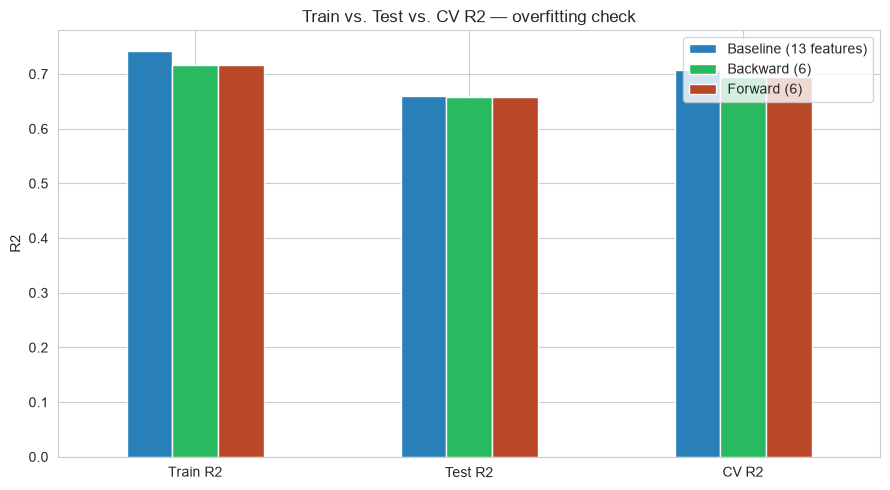

In [28]:
overfit[["Train R2", "Test R2", "CV R2"]].T.plot(
    kind="bar", figsize=(9, 5), color=["#2980b9","#29b95e", "#b94829"]
)
plt.title("Train vs. Test vs. CV R2 — overfitting check")
plt.ylabel("R2")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 11. Strategic Decision Framework: When to Use vs. When to Avoid

### When to Use

*   **Suspected Complex Feature Interaction:** When we believe features rely heavily on joint multi-variable interactions or polynomial trends to drive the target label.

*   **Moderate Dimensionality (N ≤ 40):** When our baseline feature count is small enough that training a model on the full feature space does not lead to hardware crashes or extreme execution lag.

*   **Refining Filter-Cleaned Spaces:** Highly effective as a second-stage selector after a fast Filter Method (like Pearson's correlation or ANOVA) has already reduced our initial feature count from hundreds down to a manageable size.

### When to Avoid

*   **Ultra-High Dimensionality (N > 100):** If we pass thousands of raw variables into SBS, our initial models will suffer from severe overfitting, high training times, and memory errors.

*   **When $N > \text{Number of Samples (Rows)}$:** If your dataset has more features than rows, standard linear models cannot fit a baseline because the system of equations is underdetermined. You cannot initialize Step 1 of SBS in this scenario.

---

## 12. Comprehensive Advantages & Disadvantages

### Advantages
*   **Captures Feature Interactions:** Outperforms forward selection by evaluating features within the complete context of the entire feature group.
*   **Removes Structural Redundancy:** Natively isolates and drops collinear features because their removal causes zero performance drops (since their twin column remains behind to carry the signal).

*   **Model-Specific Optimization:** Guarantees that the remaining features align directly with the structural quirks of your target architecture.

### Disadvantages
*   **High Initial Computational Overhead:** Running early iterations with near-complete feature spaces scales up compute times rapidly.

*   **Risk of Local Optima (Greedy Lock):** Once a feature is pruned/dropped by SBS, **it can never be brought back** in a later round, which can still cause it to miss certain global combinations.

*   **Sensitivity to Data Constraints:** Completely locked out from running if the input matrix contains more columns than rows (N > n).

* **Same asymptotic cost as forward** — n(n+1)/2 evaluations either direction. Choosing between them isn't about speed on a fixed n; it's
  about which blind spot you'd rather risk.

* **Same overfitting-the-folds risk as any wrapper search** — many subsets scored against the same 5 folds means the winner partly reflects those particular folds. Nested cross-validation remains the rigorous fix, not used here for the same practicality reasons as the last two notebooks.

## 13. Forward vs. Backward

| | Forward | Backward |
|---|---|---|
| Starts from | Nothing | Everything |
| First step cost | Cheap (1 feature) | Expensive (all 13) |
| Failure mode seen here | Missed true optimum at size 5 (locked in `CHAS` too early) | None observed — matched or beat forward everywhere except size 7 |
| Final one-SE answer | 6 features: LSTAT, RM, PTRATIO, CHAS, DIS, NOX | **Identical** |
| Best feasible on very wide data | Yes | No — needs the full model to fit first |

On this dataset, backward had the edge during the search but the two methods arrived at the same destination. That's a real, checked answer to
"which one should I trust" — not "they're theoretically similar," but "here is exactly where they differed, by how much, and whether it survived to the final decision."

**Next in this series:** Stepwise (bidirectional) selection — combining both directions specifically to recover from the size-5 mistake forward made here, then a move into embedded methods (Lasso, tree-based
importances) once the wrapper family is done.
